Dataset shape: (569, 30)
Class distribution:
 target
1    357
0    212
Name: count, dtype: int64
Feature sample:
                          0           1          2
mean radius        17.9900    20.57000    19.6900
mean texture       10.3800    17.77000    21.2500
mean perimeter    122.8000   132.90000   130.0000
mean area        1001.0000  1326.00000  1203.0000
mean smoothness     0.1184     0.08474     0.1096
Trained logistic
Trained rf
Trained svm
Best RF params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

=== Evaluation: logistic ===
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1: 0.9861
ROC AUC: 0.9954
Confusion Matrix:
 [[41  1]
 [ 1 71]]
Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98    

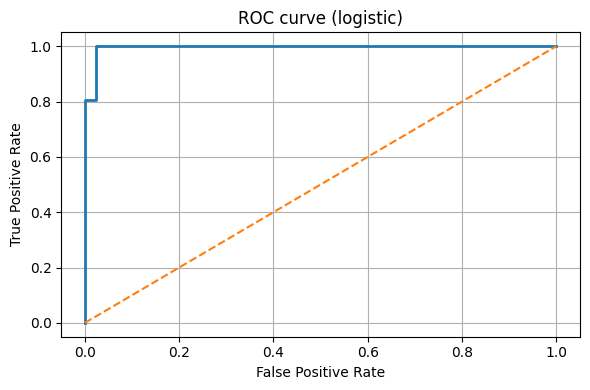


=== Evaluation: rf ===
Accuracy: 0.9561
Precision: 0.9589
Recall: 0.9722
F1: 0.9655
ROC AUC: 0.9932
Confusion Matrix:
 [[39  3]
 [ 2 70]]
Classification Report:
               precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



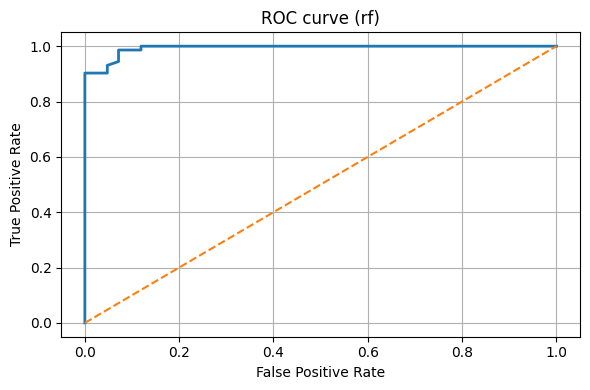


=== Evaluation: svm ===
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1: 0.9861
ROC AUC: 0.9950
Confusion Matrix:
 [[41  1]
 [ 1 71]]
Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



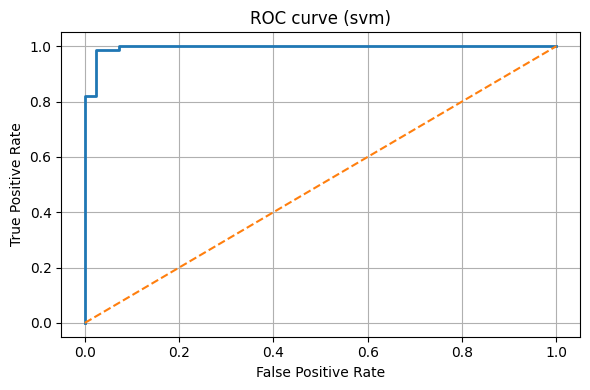


=== Evaluation: rf_tuned ===
Accuracy: 0.9561
Precision: 0.9589
Recall: 0.9722
F1: 0.9655
ROC AUC: 0.9934
Confusion Matrix:
 [[39  3]
 [ 2 70]]
Classification Report:
               precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



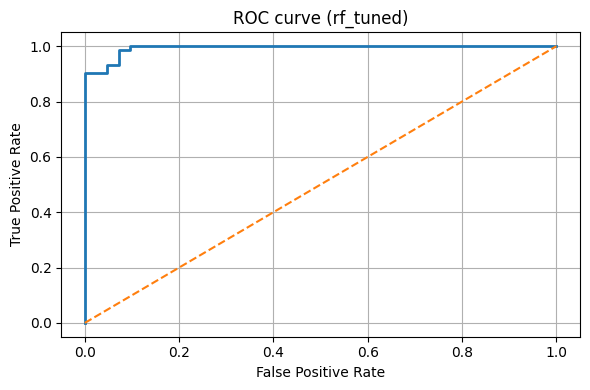

Best model by ROC AUC: logistic
Saved best model + scaler to: best_breast_cancer_model.joblib


In [1]:
"""
Breast cancer classification example (supervised learning) for a health system
-----------------------------------------------------------------------------
This script demonstrates a practical supervised learning workflow using the
scikit-learn breast cancer dataset (binary classification). It covers:
- loading data into a pandas DataFrame
- exploratory checks
- preprocessing (scaling)
- training multiple models (Logistic Regression, Random Forest, SVM)
- hyperparameter tuning (GridSearchCV for RandomForest)
- evaluation (accuracy, precision, recall, F1, ROC AUC, confusion matrix)
- saving the best model to disk

How to run:
$ python breast_cancer_classifier.py

Dependencies:
- Python 3.8+
- scikit-learn
- pandas
- numpy
- matplotlib
- joblib

Install dependencies:
$ pip install scikit-learn pandas numpy matplotlib joblib

Notes for a health system:
- This is an educational example. Do NOT deploy in production without
  proper validation, fairness checks, calibration, clinical review, and
  data governance.

"""

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)
import matplotlib.pyplot as plt
import joblib


def load_data():
    """Load breast cancer dataset and return as DataFrame + target series."""
    raw = load_breast_cancer()
    X = pd.DataFrame(raw.data, columns=raw.feature_names)
    y = pd.Series(raw.target, name='target')
    label_map = {0: 'malignant', 1: 'benign'}
    y_named = y.map(label_map)
    return X, y


def summarize_data(X, y):
    print("Dataset shape:", X.shape)
    print("Class distribution:\n", y.value_counts())
    print("Feature sample:\n", X.iloc[:3, :5].T)


def preprocess(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler


def train_models(X_train, y_train):
    models = {
        'logistic': LogisticRegression(max_iter=1000),
        'rf': RandomForestClassifier(n_estimators=200, random_state=42),
        'svm': SVC(probability=True, gamma='scale'),
    }

    fitted = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        fitted[name] = model
        print(f"Trained {name}")
    return fitted


def tune_random_forest(X_train, y_train):
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5],
    }
    rf = RandomForestClassifier(random_state=42)
    gs = GridSearchCV(rf, param_grid, cv=4, scoring='roc_auc', n_jobs=-1)
    gs.fit(X_train, y_train)
    print("Best RF params:", gs.best_params_)
    return gs.best_estimator_


def evaluate_model(model, X_test, y_test, model_name='model'):
    probs = None
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        probs = model.decision_function(X_test)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc = roc_auc_score(y_test, probs) if probs is not None else float('nan')

    print(f"\n=== Evaluation: {model_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"ROC AUC: {roc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("Classification Report:\n", classification_report(y_test, preds, target_names=['malignant','benign']))

    if probs is not None:
        fpr, tpr, _ = roc_curve(y_test, probs)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, linewidth=2)
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.title(f'ROC curve ({model_name})')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc,
    }


def main(save_model_path='best_breast_cancer_model.joblib'):
    # 1. Load
    X, y = load_data()
    summarize_data(X, y)

    # 2. Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 3. Preprocess
    X_train_scaled, X_test_scaled, scaler = preprocess(X_train, X_test)

    # 4. Train baseline models
    fitted = train_models(X_train_scaled, y_train)

    # 5. Hyperparameter tune Random Forest
    best_rf = tune_random_forest(X_train_scaled, y_train)
    fitted['rf_tuned'] = best_rf

    # 6. Evaluate all models on test set
    results = {}
    for name, model in fitted.items():
        results[name] = evaluate_model(model, X_test_scaled, y_test, model_name=name)

    # 7. Pick best by roc_auc
    best_name = max(results.keys(), key=lambda n: (results[n]['roc_auc'] if not np.isnan(results[n]['roc_auc']) else -1))
    print(f"Best model by ROC AUC: {best_name}")

    # 8. Save best model and scaler
    joblib.dump({'model': fitted[best_name], 'scaler': scaler}, save_model_path)
    print(f"Saved best model + scaler to: {save_model_path}")


if __name__ == '__main__':
    main()
